In [11]:
# ============================================================
# LOAD DATA + PERSIAPAN DATA UNTUK MODELING
# ============================================================

import pandas as pd
import numpy as np
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("LOAD DATA + PERSIAPAN DATA UNTUK MODELING")
print("="*80)

# ============================================================
# 1. LOAD DATA DARI GOOGLE SHEETS
# ============================================================

print("\n📊 1. Load Data dari Google Sheets")

CREDENTIALS_PATH = r"C:\Users\fardh\Skripsi\Folder Baru\bim-flight-demo\credentials\credentials.json"
GOOGLE_SHEET_KEY = "1njLUn55TWwYjTQKEmmR97bcwgYaLYdF-0j5vK-vUIRw"

scope = [
    "https://spreadsheets.google.com/feeds",
    "https://www.googleapis.com/auth/drive"
]

creds = ServiceAccountCredentials.from_json_keyfile_name(CREDENTIALS_PATH, scope)
gc = gspread.authorize(creds)
sheet = gc.open_by_key(GOOGLE_SHEET_KEY)

# Ambil data dari sheet DATA_FINAL
worksheet = sheet.worksheet("DATA_FINAL")
data = worksheet.get_all_records()
df = pd.DataFrame(data)

print(f"\n✅ Data berhasil dimuat:")
print(f"   Total baris : {len(df):,}")
print(f"   Total kolom : {len(df.columns)}")

# ============================================================
# 2. KONVERSI TIPE DATA
# ============================================================

print("\n📊 2. Konversi Tipe Data")

# Konversi Arrival_Date ke datetime
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'], errors='coerce')

# Kolom numerik
numeric_cols = ['Arrival_Delay', 'Turnaround_Time', 'Departure_Hour', 
                'Month', 'Departure_Delay', 'Delay_Category_Encoded', 'Airline_Encoded']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"   ✅ {col:25s} : numeric")

# Kolom boolean
bool_cols = ['Peak_Hour', 'Is_Weekend']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})
        df[col] = df[col].fillna(0).astype(int)
        print(f"   ✅ {col:25s} : boolean (0/1)")

print(f"\n   Total baris  : {len(df):,}")
print(f"   Total kolom  : {len(df.columns)}")
print(f"   Missing value: {df.isna().sum().sum():,}")

# ============================================================
# 3. CEK KELENGKAPAN KOLOM ENCODING
# ============================================================

print("\n📊 3. Cek Kelengkapan Kolom Encoding")

categorical_cols = [
    "Airline",
    "Aircraft_Type",
    "Origin",
    "Destination",
    "Departure_Period",
    "Stand",
    "Day_of_Week"
]

print("\n   Status Encoding:")
print("   " + "-"*60)
for col in categorical_cols:
    if col in df.columns:
        encoded_col = col + "_Encoded"
        if encoded_col in df.columns:
            print(f"   ✅ {col:20s} → {encoded_col:25s} (sudah di-encode)")
        else:
            print(f"   ⚠️ {col:20s} → {encoded_col:25s} (BELUM di-encode!)")
    else:
        print(f"   ❌ {col:20s} (tidak ditemukan)")

# Cek target
if "Delay_Category_Encoded" in df.columns:
    print(f"   ✅ Delay_Category_Encoded (target sudah di-encode)")
else:
    print(f"   ❌ Delay_Category_Encoded (target BELUM di-encode!)")
print("   " + "-"*60)

# ============================================================
# 4. ENCODING KOLOM KATEGORIKAL
# ============================================================

print("\n📊 4. Encoding Kolom Kategorikal")

# Kolom yang perlu di-encode (belum di-encode)
cols_to_encode = [
    'Aircraft_Type',
    'Origin',
    'Destination',
    'Departure_Period',
    'Stand',
    'Day_of_Week'
]

# Buat salinan data
df_model = df.copy()

# Encode kolom
encoders = {}
for col in cols_to_encode:
    le = LabelEncoder()
    # Handle missing values
    df_model[col] = df_model[col].fillna('UNKNOWN').astype(str)
    df_model[col + '_Encoded'] = le.fit_transform(df_model[col])
    encoders[col] = le
    print(f"   ✅ {col:20s} → {col+'_Encoded':25s} : {len(le.classes_):>3} unique values")

print(f"\n   ✅ Total kolom di-encode: {len(cols_to_encode)} kolom")

# ============================================================
# 5. PILIH FITUR (X) DAN TARGET (y)
# ============================================================

print("\n📊 5. Pilih Fitur (X) dan Target (y)")

# Fitur yang akan digunakan (13 fitur)
features = [
    # Kategorikal (encoded)
    'Airline_Encoded',
    'Aircraft_Type_Encoded',
    'Origin_Encoded',
    'Destination_Encoded',
    'Departure_Period_Encoded',
    'Stand_Encoded',
    'Day_of_Week_Encoded',
    
    # Numerik
    'Arrival_Delay',
    'Turnaround_Time',
    'Departure_Hour',
    'Month',
    
    # Boolean
    'Peak_Hour',
    'Is_Weekend'
]

target = 'Delay_Category_Encoded'

# Buat X dan y
X = df_model[features]
y = df_model[target]

print(f"\n   Jumlah Fitur (X) : {len(features)} fitur")
print(f"   Target (y)       : {target}")

print("\n   Daftar Fitur:")
for i, feat in enumerate(features, 1):
    print(f"      {i:2d}. {feat}")

print(f"\n   X shape : {X.shape}")
print(f"   y shape : {y.shape}")

# ============================================================
# 6. DISTRIBUSI TARGET
# ============================================================

print("\n📊 6. Distribusi Target (Delay Category)")

target_mapping = {0: 'OTP', 1: 'K1', 2: 'K2', 3: 'K3', 4: 'K4', 5: 'K5'}

print("\n   Distribusi Target:")
print("   " + "-"*45)
for idx, count in y.value_counts().sort_index().items():
    label = target_mapping.get(idx, f'K{idx}')
    pct = count / len(y) * 100
    bar = "█" * int(pct / 2)
    print(f"   {label:12s} : {count:>5,} ({pct:>5.1f}%) {bar}")
print("   " + "-"*45)

# ============================================================
# 7. SPLIT DATA BERDASARKAN TANGGAL (70:15:15)
# ============================================================

print("\n📊 7. Split Data Berdasarkan Tanggal (70:15:15)")

# Gabungkan X dan y dengan tanggal
df_sorted = df_model[['Arrival_Date'] + features + [target]].copy()
df_sorted = df_sorted.sort_values('Arrival_Date').reset_index(drop=True)

total_data = len(df_sorted)
train_size = int(total_data * 0.70)
val_size = int(total_data * 0.15)

print(f"\n   Total data      : {total_data:,}")
print(f"   Training (70%)  : {train_size:,} data")
print(f"   Validation (15%): {val_size:,} data")
print(f"   Test (15%)      : {total_data - train_size - val_size:,} data")

# Split
X_train = df_sorted.iloc[:train_size][features]
y_train = df_sorted.iloc[:train_size][target]

X_val = df_sorted.iloc[train_size:train_size+val_size][features]
y_val = df_sorted.iloc[train_size:train_size+val_size][target]

X_test = df_sorted.iloc[train_size+val_size:][features]
y_test = df_sorted.iloc[train_size+val_size:][target]

print(f"\n   Periode Split:")
print(f"   Training   : {df_sorted.iloc[0]['Arrival_Date']} s/d {df_sorted.iloc[train_size-1]['Arrival_Date']}")
print(f"   Validation : {df_sorted.iloc[train_size]['Arrival_Date']} s/d {df_sorted.iloc[train_size+val_size-1]['Arrival_Date']}")
print(f"   Test       : {df_sorted.iloc[train_size+val_size]['Arrival_Date']} s/d {df_sorted.iloc[-1]['Arrival_Date']}")

# ============================================================
# 8. CEK DISTRIBUSI TARGET PER SPLIT
# ============================================================

print("\n📊 8. Distribusi Target per Split")

for name, y_data in [('Training', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f"\n   {name} ({len(y_data):,} data):")
    dist = y_data.value_counts().sort_index()
    for idx, count in dist.items():
        label = target_mapping.get(idx, f'K{idx}')
        pct = count / len(y_data) * 100
        print(f"      {label:12s} : {count:>5,} ({pct:>5.1f}%)")

# ============================================================
# TAMBAHKAN DI AKHIR CELL 1 (SETELAH SPLIT DATA)
# ============================================================

print("\n📊 9. Gabungkan Kelas Minoritas (K2, K3, K4)")

# Mapping baru untuk kelas gabungan
target_mapping_combined = {0: 'OTP', 1: 'K1', 2: 'Minor_Delay', 5: 'K5'}

# Fungsi untuk menggabungkan kelas minoritas
def combine_minority_classes(y):
    """Gabungkan K2, K3, K4 menjadi satu kelas 'Minor_Delay'"""
    y_new = y.copy()
    # K2(2), K3(3), K4(4) → 2 (Minor_Delay)
    y_new = y_new.replace({2: 2, 3: 2, 4: 2})
    return y_new

# Terapkan pada semua data
y_train_combined = combine_minority_classes(y_train)
y_val_combined = combine_minority_classes(y_val)
y_test_combined = combine_minority_classes(y_test)

print("\n   Distribusi Training setelah penggabungan:")
train_dist_combined = pd.Series(y_train_combined).value_counts().sort_index()
for idx, count in train_dist_combined.items():
    label = target_mapping_combined.get(idx, f'K{idx}')
    pct = count / len(y_train_combined) * 100
    print(f"      {label}: {count:,} ({pct:.1f}%)")
print("\n✅ PERSIAPAN DATA SELESAI!")
print("📊 Data siap untuk TAHAP 5: MODELING")
print("="*80)


LOAD DATA + PERSIAPAN DATA UNTUK MODELING

📊 1. Load Data dari Google Sheets

✅ Data berhasil dimuat:
   Total baris : 2,574
   Total kolom : 21

📊 2. Konversi Tipe Data
   ✅ Arrival_Delay             : numeric
   ✅ Turnaround_Time           : numeric
   ✅ Departure_Hour            : numeric
   ✅ Month                     : numeric
   ✅ Departure_Delay           : numeric
   ✅ Delay_Category_Encoded    : numeric
   ✅ Airline_Encoded           : numeric
   ✅ Peak_Hour                 : boolean (0/1)
   ✅ Is_Weekend                : boolean (0/1)

   Total baris  : 2,574
   Total kolom  : 21
   Missing value: 0

📊 3. Cek Kelengkapan Kolom Encoding

   Status Encoding:
   ------------------------------------------------------------
   ✅ Airline              → Airline_Encoded           (sudah di-encode)
   ⚠️ Aircraft_Type        → Aircraft_Type_Encoded     (BELUM di-encode!)
   ⚠️ Origin               → Origin_Encoded            (BELUM di-encode!)
   ⚠️ Destination          → Destination


TAHAP 5: MODELING - RANDOM FOREST DENGAN SMOTE

 1. Distribusi Data Training (Kelas Gabungan):
      OTP: 314 (17.4%)
      K1: 236 (13.1%)
      Minor_Delay: 103 (5.7%)
      K5: 1,148 (63.7%)

 2. SMOTE untuk Menyeimbangkan Data

   Data training asli      : 1,801 sampel
   Data training setelah SMOTE: 4,592 sampel

   Distribusi SETELAH SMOTE:
      OTP: 1,148 (25.0%)
      K1: 1,148 (25.0%)
      Minor_Delay: 1,148 (25.0%)
      K5: 1,148 (25.0%)

 3. Hyperparameter Tuning dengan SMOTE
   Kombinasi parameter: 144 kombinasi
   Estimasi waktu: ~72 detik

  Mencari parameter terbaik... (proses ini memakan waktu)
Fitting 5 folds for each of 144 candidates, totalling 720 fits

    Best Parameters: {'rf__max_depth': 25, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 150}
     Best CV Score (F1-Macro): 0.7851
     Waktu tuning: 69.42 detik

 4. Evaluasi Model Terbaik

    METRIK EVALUASI (Test Set):
   Metrik                         Nilai
   ------------------

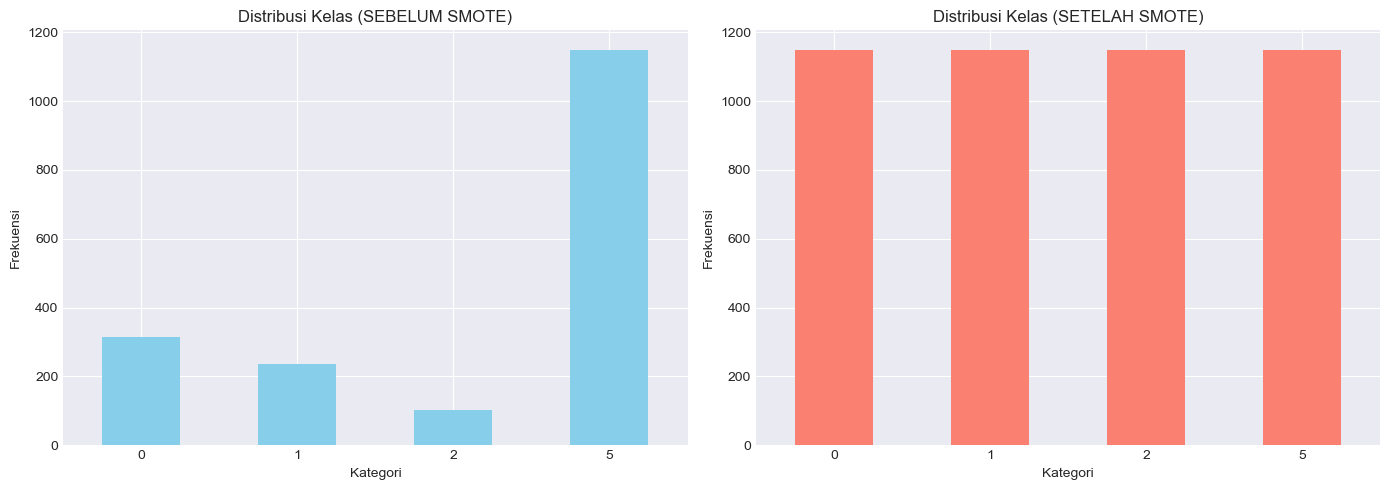

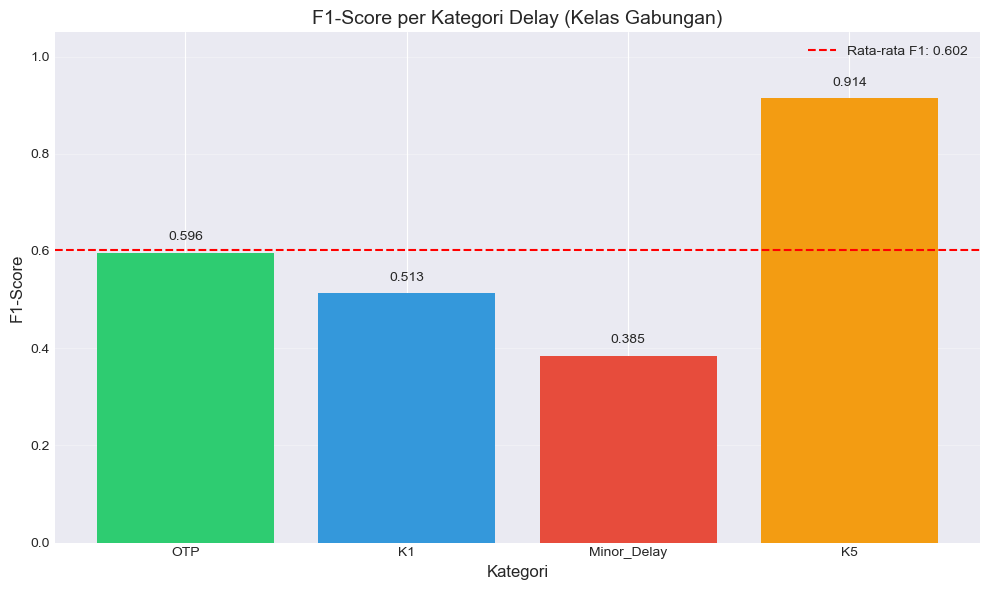

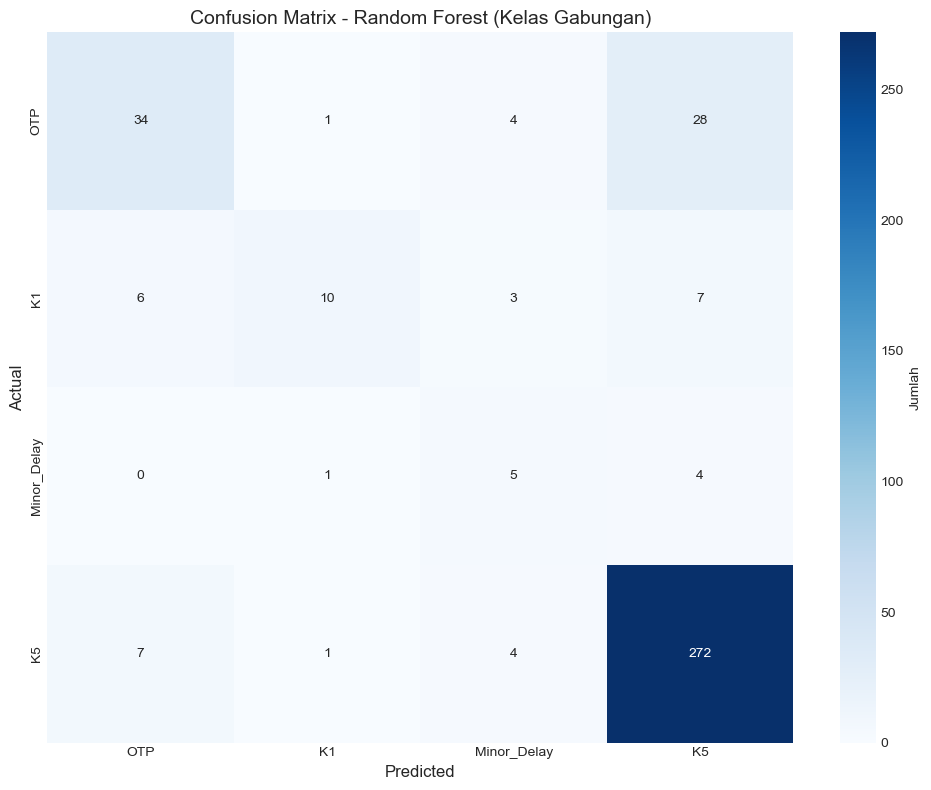

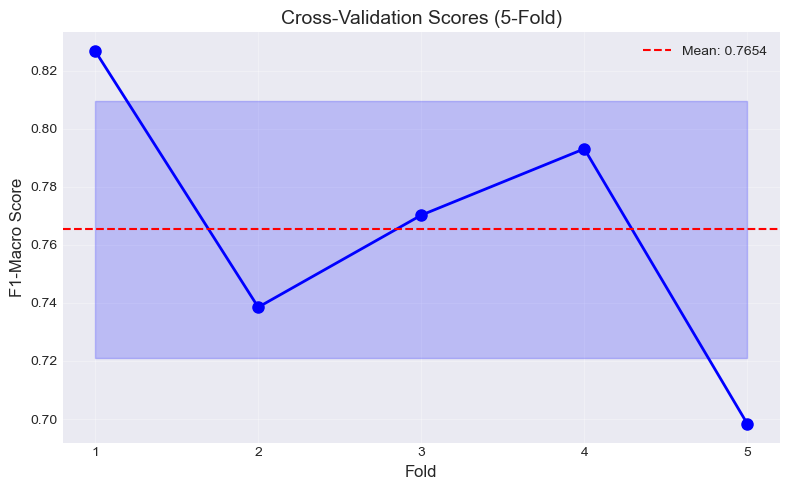


 9. Feature Importance

   Top 10 Fitur Terpenting:
   ----------------------------------------------------------------------
   Arrival_Delay                  : 0.4225 (42.25%) █████████████████████████████
   Turnaround_Time                : 0.1139 (11.39%) ███████
   Departure_Hour                 : 0.0903 (9.03%) ██████
   Airline_Encoded                : 0.0710 (7.10%) ████
   Destination_Encoded            : 0.0483 (4.83%) ███
   Stand_Encoded                  : 0.0440 (4.40%) ███
   Day_of_Week_Encoded            : 0.0414 (4.14%) ██
   Origin_Encoded                 : 0.0409 (4.09%) ██
   Month                          : 0.0396 (3.96%) ██
   Departure_Period_Encoded       : 0.0338 (3.38%) ██


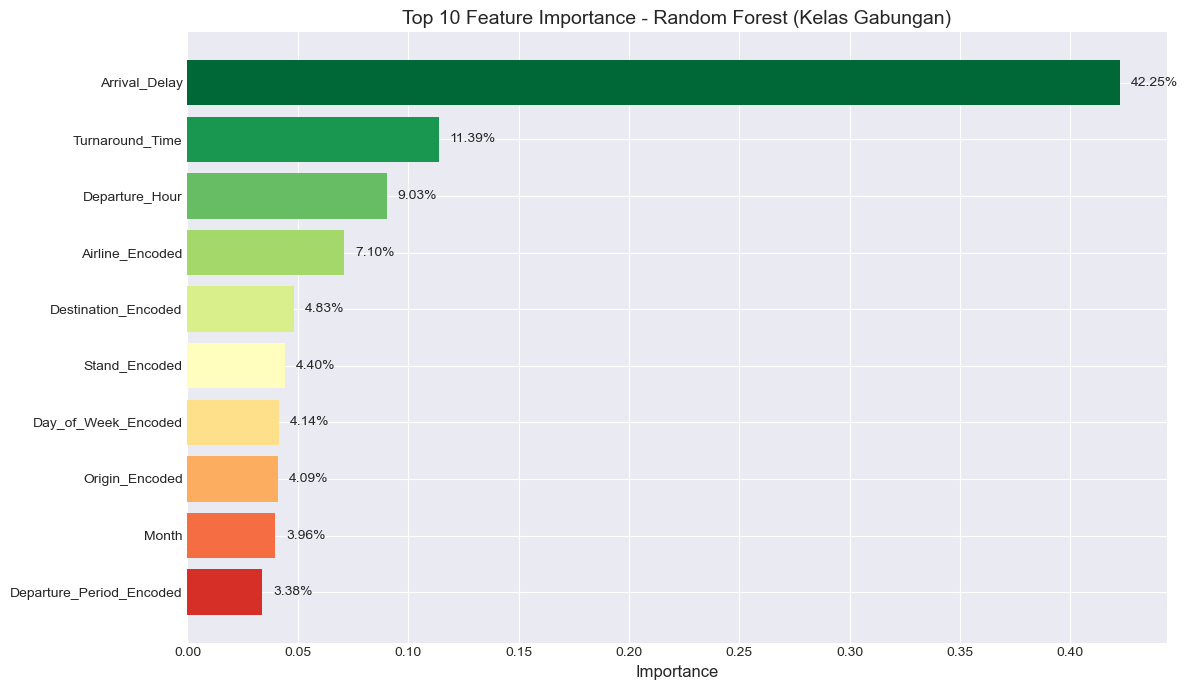


 10. Perbandingan Model Baseline vs Final

    PERBANDINGAN METRIK:
   Metrik                      Baseline           Final       Perubahan
   -----------------------------------------------------------------
   F1-Macro                      0.6067          0.6021          -0.46%
   F1-Weighted                   0.8289          0.8186          -1.03%
   Accuracy                      0.8424          0.8295          -1.29%

 RINGKASAN HASIL MODELING (KELAS GABUNGAN)

┌─────────────────────────────────────────────────────────────────────────────┐
│                    RINGKASAN HASIL MODELING (KELAS GABUNGAN)              │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Data                                                                   │
│     Total data      : 2,574                                           │
│     Training (70%)  : 1,801 (setelah SMOTE: 4,592)│
│     

In [15]:
# ============================================================
# TAHAP 5: MODELING - RANDOM FOREST DENGAN SMOTE
# ============================================================

# ============================================================
# IMPORT LIBRARY
# ============================================================

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Setting visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("\n" + "="*80)
print("TAHAP 5: MODELING - RANDOM FOREST DENGAN SMOTE")
print("="*80)

# ============================================================
# 1. CEK DISTRIBUSI DATA (SUDAH DIGABUNGKAN)
# ============================================================

print("\n 1. Distribusi Data Training (Kelas Gabungan):")
train_dist = pd.Series(y_train_combined).value_counts().sort_index()
for idx, count in train_dist.items():
    label = target_mapping_combined.get(idx, f'K{idx}')
    pct = count / len(y_train_combined) * 100
    print(f"      {label}: {count:,} ({pct:.1f}%)")

# ============================================================
# 2. SMOTE UNTUK MENYEMBANGKAN DATA
# ============================================================

print("\n 2. SMOTE untuk Menyeimbangkan Data")

# Terapkan SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_combined)

print(f"\n   Data training asli      : {X_train.shape[0]:,} sampel")
print(f"   Data training setelah SMOTE: {X_train_resampled.shape[0]:,} sampel")

print("\n   Distribusi SETELAH SMOTE:")
train_dist_resampled = pd.Series(y_train_resampled).value_counts().sort_index()
for idx, count in train_dist_resampled.items():
    label = target_mapping_combined.get(idx, f'K{idx}')
    pct = count / len(y_train_resampled) * 100
    print(f"      {label}: {count:,} ({pct:.1f}%)")

# ============================================================
# 3. HYPERPARAMETER TUNING DENGAN SMOTE
# ============================================================

print("\n 3. Hyperparameter Tuning dengan SMOTE")

# Pipeline dengan ImbPipeline
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('rf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])

# Parameter grid yang lebih luas
param_grid_pipeline = {
    'rf__n_estimators': [100, 150, 200, 250],
    'rf__max_depth': [15, 20, 25, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

total_combinations = (
    len(param_grid_pipeline['rf__n_estimators']) * 
    len(param_grid_pipeline['rf__max_depth']) * 
    len(param_grid_pipeline['rf__min_samples_split']) * 
    len(param_grid_pipeline['rf__min_samples_leaf'])
)
print(f"   Kombinasi parameter: {total_combinations} kombinasi")
print(f"   Estimasi waktu: ~{total_combinations * 0.5:.0f} detik")

# StratifiedKFold untuk menjaga proporsi kelas
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid_pipeline,
    cv=skf,
    scoring='f1_macro',  # F1-Macro lebih adil untuk data tidak seimbang
    n_jobs=-1,
    verbose=1
)

print("\n  Mencari parameter terbaik... (proses ini memakan waktu)")
start_time = time.time()
grid_search.fit(X_train,
                y_train_combined)
end_time = time.time()

print(f"\n    Best Parameters: {grid_search.best_params_}")
print(f"     Best CV Score (F1-Macro): {grid_search.best_score_:.4f}")
print(f"     Waktu tuning: {end_time - start_time:.2f} detik")

# ============================================================
# 4. EVALUASI MODEL TERBAIK
# ============================================================

print("\n 4. Evaluasi Model Terbaik")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Metrik evaluasi
accuracy = accuracy_score(y_test_combined, y_pred)
precision_weighted = precision_score(y_test_combined, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test_combined, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test_combined, y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_test_combined, y_pred, average='macro', zero_division=0)

print("\n    METRIK EVALUASI (Test Set):")
print(f"   {'Metrik':<20} {'Nilai':>15}")
print(f"   {'-'*37}")
print(f"   {'Accuracy':<20} {accuracy:>15.4f}")
print(f"   {'Precision (weighted)':<20} {precision_weighted:>15.4f}")
print(f"   {'Recall (weighted)':<20} {recall_weighted:>15.4f}")
print(f"   {'F1-Score (weighted)':<20} {f1_weighted:>15.4f}")
print(f"   {'F1-Score (macro)':<20} {f1_macro:>15.4f}")

# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================

print("\n 5. Classification Report (Test Set):")

# Ambil unique labels yang sebenarnya ada
unique_labels = sorted(set(y_test_combined))
target_names = [target_mapping_combined.get(i, f'K{i}') for i in unique_labels]

print(classification_report(
    y_test_combined, 
    y_pred, 
    labels=unique_labels,
    target_names=target_names, 
    zero_division=0
))

# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

print("\n 6. Confusion Matrix (Test Set):")

cm = confusion_matrix(y_test_combined, y_pred, labels=unique_labels)

print("\n   Confusion Matrix (Actual → Predicted):")
print("   " + "="*80)
print(f"   {'':<14} |", end="")
for i in range(len(cm)):
    print(f" {target_names[i]:>12}", end="")
print()
print("   " + "-"*80)
for i, row in enumerate(cm):
    print(f"   {target_names[i]:>12} |", end="")
    for val in row:
        print(f" {val:>12}", end="")
    print()
print("   " + "="*80)

# ============================================================
# 7. CROSS-VALIDATION (VALIDASI MODEL)
# ============================================================

print("\n 7. Cross-Validation (5-Fold)")

# Gunakan model terbaik untuk cross-validation
cv_scores = cross_val_score(
    best_model, 
    X_train, 
    y_train_combined, 
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1
)

print(f"\n    Hasil Cross-Validation (5-Fold):")
print(f"   {'Fold':<10} {'F1-Macro':>15}")
print(f"   {'-'*27}")
for i, score in enumerate(cv_scores, 1):
    print(f"   {'Fold ' + str(i):<10} {score:>15.4f}")
print(f"   {'-'*27}")
print(f"   {'Mean':<10} {cv_scores.mean():>15.4f}")
print(f"   {'Std':<10} {cv_scores.std():>15.4f}")

print(f"\n    Model stabil dengan variasi {cv_scores.std():.4f}")

# ============================================================
# 8. VISUALISASI
# ============================================================

print("\n 8. Visualisasi Hasil")

# Plot 1: Perbandingan distribusi kelas
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
train_dist.plot(kind='bar', color='skyblue')
plt.title('Distribusi Kelas (SEBELUM SMOTE)')
plt.xlabel('Kategori')
plt.ylabel('Frekuensi')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
train_dist_resampled.plot(kind='bar', color='salmon')
plt.title('Distribusi Kelas (SETELAH SMOTE)')
plt.xlabel('Kategori')
plt.ylabel('Frekuensi')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Plot 2: F1-Score per kelas
plt.figure(figsize=(10, 6))
f1_per_class = f1_score(y_test_combined, y_pred, labels=unique_labels, average=None, zero_division=0)
bars = plt.bar(target_names, f1_per_class, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
plt.axhline(y=f1_per_class.mean(), color='red', linestyle='--', 
            label=f'Rata-rata F1: {f1_per_class.mean():.3f}')
plt.title('F1-Score per Kategori Delay (Kelas Gabungan)', fontsize=14)
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for bar, value in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Plot 3: Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names,
            cbar_kws={'label': 'Jumlah'})
plt.title('Confusion Matrix - Random Forest (Kelas Gabungan)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 4: Cross-Validation Scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
            label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), alpha=0.2, color='blue')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('F1-Macro Score', fontsize=12)
plt.title('Cross-Validation Scores (5-Fold)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

print("\n 9. Feature Importance")

# Ambil model Random Forest dari pipeline
rf_model = best_model.named_steps['rf']

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n   Top 10 Fitur Terpenting:")
print("   " + "-"*70)
for i, row in feature_importance.head(10).iterrows():
    bar = "█" * int(row['Importance'] * 70)
    print(f"   {row['Feature']:30s} : {row['Importance']:.4f} ({row['Importance']*100:.2f}%) {bar}")

# Plot Feature Importance
plt.figure(figsize=(12, 7))
top_features = feature_importance.head(10)
colors = plt.cm.RdYlGn_r([i/len(top_features) for i in range(len(top_features))])
plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Feature Importance - Random Forest (Kelas Gabungan)', fontsize=14)
plt.gca().invert_yaxis()

# Tambahkan nilai di samping bar
for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.text(row['Importance'] + 0.005, i, f'{row["Importance"]*100:.2f}%', 
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================
# 10. PERBANDINGAN MODEL (BASELINE vs FINAL)
# ============================================================

print("\n 10. Perbandingan Model Baseline vs Final")

# Train model baseline (tanpa SMOTE)
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train_combined)
y_pred_baseline = rf_baseline.predict(X_test)

# Metrik baseline
f1_macro_baseline = f1_score(y_test_combined, y_pred_baseline, average='macro', zero_division=0)
f1_weighted_baseline = f1_score(y_test_combined, y_pred_baseline, average='weighted', zero_division=0)

print("\n    PERBANDINGAN METRIK:")
print(f"   {'Metrik':<20} {'Baseline':>15} {'Final':>15} {'Perubahan':>15}")
print(f"   {'-'*65}")
print(f"   {'F1-Macro':<20} {f1_macro_baseline:>15.4f} {f1_macro:>15.4f} {(f1_macro - f1_macro_baseline)*100:>+14.2f}%")
print(f"   {'F1-Weighted':<20} {f1_weighted_baseline:>15.4f} {f1_weighted:>15.4f} {(f1_weighted - f1_weighted_baseline)*100:>+14.2f}%")
print(f"   {'Accuracy':<20} {accuracy_score(y_test_combined, y_pred_baseline):>15.4f} {accuracy:>15.4f} {(accuracy - accuracy_score(y_test_combined, y_pred_baseline))*100:>+14.2f}%")

# ============================================================
# 11. RINGKASAN
# ============================================================

print("\n" + "="*80)
print(" RINGKASAN HASIL MODELING (KELAS GABUNGAN)")
print("="*80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    RINGKASAN HASIL MODELING (KELAS GABUNGAN)              │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Data                                                                   │
│     Total data      : {len(X):,}                                           │
│     Training (70%)  : {len(X_train):,} (setelah SMOTE: {X_train_resampled.shape[0]:,})│
│     Validation (15%): {len(X_val):,}                                       │
│     Test (15%)      : {len(X_test):,}                                      │
│                                                                             │
│   METRIK EVALUASI (Test Set)                                             │
│     Accuracy         : {accuracy:.4f}                                      │
│     F1-Score (weighted): {f1_weighted:.4f}                                 │
│     F1-Score (macro) : {f1_macro:.4f}                                      │
│                                                                             │
│   PERFORMANCE PER KATEGORI (F1-Score)                                    │
""")

for i, label in enumerate(target_names):
    if i < len(f1_per_class):
        f1_class = f1_per_class[i]
        # Rating berdasarkan F1-Score
        if f1_class >= 0.80:
            rating = " Sangat Baik"
        elif f1_class >= 0.60:
            rating = " Baik"
        elif f1_class >= 0.40:
            rating = " Cukup"
        else:
            rating = " Perlu Perbaikan"
        print(f"│     {label:12s} : {f1_class:.4f}  ({rating})                     │")

print(f"""
│                                                                             │
│   PARAMETER TERBAIK                                                      │
│     {grid_search.best_params_}                                             │
│                                                                             │
│   CROSS-VALIDATION (5-Fold)                                              │
│     Mean F1-Macro : {cv_scores.mean():.4f}                                 │
│     Std Dev       : {cv_scores.std():.4f}                                  │
│                                                                             │
│   PENINGKATAN DARI BASELINE                                              │
│     F1-Macro : {f1_macro_baseline:.4f} → {f1_macro:.4f} ({(f1_macro - f1_macro_baseline)*100:+.1f}%)│
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ MODELING DENGAN KELAS GABUNGAN SELESAI!")
print("="*80)

In [ ]:
# ============================================================
# EXPORT MODEL DAN ENCODERS UNTUK DASHBOARD
# ============================================================

import joblib
import pickle
import os

# 1. Pastikan model terbaik sudah ada (dari hasil GridSearchCV)
best_model = grid_search.best_estimator_

# 2. Buat folder untuk menyimpan model (jika belum ada)
os.makedirs('prediksi_delay', exist_ok=True)

# 3. Simpan model Random Forest
joblib.dump(best_model, 'prediksi_delay/model.pkl')
print("✅ Model saved to: prediksi_delay/model.pkl")

# 4. Simpan encoder dan mapping
with open('prediksi_delay/encoders.pkl', 'wb') as f:
    pickle.dump({
        'encoders': encoders,
        'target_mapping_combined': target_mapping_combined,
        'features': features
    }, f)
print("✅ Encoders saved to: prediksi_delay/encoders.pkl")

# 5. Verifikasi file sudah terbuat
print("\n📁 File yang tersimpan:")
print("   - prediksi_delay/model.pkl")
print("   - prediksi_delay/encoders.pkl")